# 变量变换与多元积分

学习目标：按区域写出二重积分与换序界限，使用雅可比因子完成积分和密度变换，并判断单调性、可逆性及奇异点带来的限制。

前置知识：定积分、矩形区域二重积分、联合密度、偏导数、雅可比矩阵、二阶行列式、NumPy 数组操作。

运行环境：Python 3.12、NumPy 2.x、SciPy 1.18、Matplotlib 3.11；本章使用 CPU 上的小型教学计算，完整版本见环境说明。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

本章是扩展内容。坐标和随机变量均取实数，示例均无物理单位。随机样本只用于观察公式的结果，不代替定理或推导。

## 1 先沿三角形的一条方向积分

设 $x,y$ 是平面坐标，三角区域为

$$D=\{(x,y):0\le x\le1,\ 0\le y\le x\}.$$

固定一个 $x$，竖直线段上的 $y$ 从 0 到 $x$。以 $f(x,y)=x+y$ 为被积函数，$dA$ 表示面积元素，先对 $y$ 积分：

$$\iint_D(x+y)\,dA
=\int_0^1\left[xy+\frac{y^2}{2}\right]_{y=0}^{y=x}dx
=\int_0^1\frac32x^2\,dx=\frac12.$$

这里的内层上限随外层变量变化。若把两个坐标都取 0 到 1，区域会变成正方形。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import dblquad, quad

# 用已经手算出的内层积分核对，不先把全部计算交给二重积分函数。
triangle_value, triangle_error = quad(lambda x: 1.5 * x**2, 0, 1)
print("三角区域积分：", triangle_value)  # 预期接近 1/2。
print("与手算结果的差：", abs(triangle_value - 0.5))  # 预期接近 0；本次计算为 0。
print("数值积分器报告的误差估计：", triangle_error)  # 本次数值约为 5.6e-15。

三角区域积分： 0.5
与手算结果的差： 0.0
数值积分器报告的误差估计： 5.551115123125783e-15


## 2 简单区域与积分界限

区域可以按竖直切片或水平切片描述。下表中 $a<b$、$c<d$ 是有限实数；$g_1,g_2$ 和 $h_1,h_2$ 是连续边界函数，下界不超过上界。

| 名称 | 中文名称／含义 | 区域及积分次序 |
| --- | --- | --- |
| Type I region | 第一型区域；固定 $x$ 后，$y$ 落在一段区间 | $a\le x\le b,\ g_1(x)\le y\le g_2(x)$；先 $dy$ 后 $dx$ |
| Type II region | 第二型区域；固定 $y$ 后，$x$ 落在一段区间 | $c\le y\le d,\ h_1(y)\le x\le h_2(y)$；先 $dx$ 后 $dy$ |

在本章的有界、边界分段光滑区域上，连续函数可以按对应切片做累次积分。有些区域两种形式都能使用；有些区域换序后必须分成几块，各块内部不重叠，再将积分相加。

三角形 $D$ 的另一种描述是 $0\le y\le1$、$y\le x\le1$。下图用同一个区域比较两种切片，蓝色为竖直切片，橙色为水平切片。

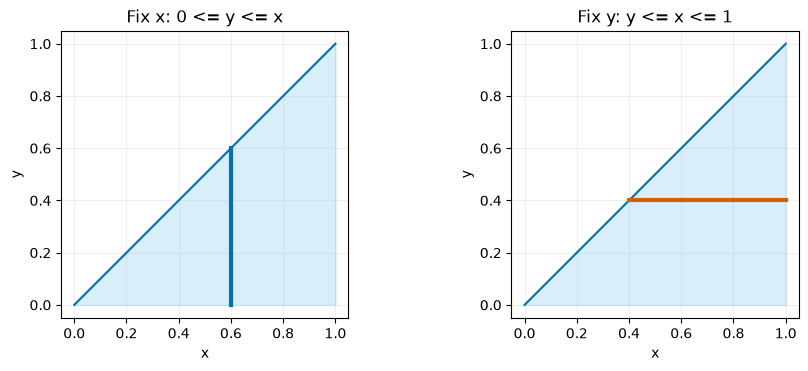

In [2]:
grid = np.linspace(0, 1, 201)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
for ax in axes:
    ax.fill_between(grid, 0, grid, color="#56B4E9", alpha=0.22)
    ax.plot(grid, grid, color="#0072B2")
    ax.set(xlabel="x", ylabel="y", xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
axes[0].plot([0.6, 0.6], [0, 0.6], color="#0072B2", linewidth=3)
axes[0].set_title("Fix x: 0 <= y <= x")
axes[1].plot([0.4, 1], [0.4, 0.4], color="#D55E00", linewidth=3)
axes[1].set_title("Fix y: y <= x <= 1")
# 预期两图阴影是同一个直角三角形；左图竖线、右图横线展示不同的积分次序。
plt.show()  # 两幅图的三角形完全相同，变化的是切片方向。

换序要重写界限，不能只交换 $dx$ 和 $dy$。对同一个三角形，

$$\int_0^1\int_y^1(x+y)\,dx\,dy
=\int_0^1\left(\frac12+y-\frac32y^2\right)dy=\frac12.$$

SciPy 的 dblquad 将内层变量放在被积函数的第一个参数，外层变量放在第二个参数。外层上下限是两个数，内层上下限可以是外层变量的函数。它返回积分值和误差估计；后者不是数学证明，也不是所有误差的严格上界。

In [3]:
# 第一次调用：内层 y，外层 x；第二次调用：内层 x，外层 y。
dy_dx, error_dy_dx = dblquad(lambda y, x: x + y, 0, 1, 0, lambda x: x)
dx_dy, error_dx_dy = dblquad(lambda x, y: x + y, 0, 1, lambda y: y, 1)
square_value, _ = dblquad(lambda y, x: x + y, 0, 1, 0, 1)
print("两种次序：", dy_dx, dx_dy)  # 预期都接近 0.5。
print("两者差值：", abs(dy_dx - dx_dy))  # 预期接近 0；本次计算为 0。
print("各自误差估计：", error_dy_dx, error_dx_dy)  # 本次数值约为 1.7e-14 7.4e-15。
print("误用正方形界限：", square_value)  # 预期为 1，已算成另一个问题。

两种次序： 0.5 0.5
两者差值： 0.0
各自误差估计： 1.6581101126856638e-14 7.395173713084844e-15
误用正方形界限： 1.0


## 3 换序需要成立条件

连续函数在前述紧区域上的积分是本章主要情形。遇到无界区域或函数在某处发散时，要重新判断可积性。下面两种充分条件使用 Lebesgue 积分表述；本章只使用由连续函数、分段函数及其简单区域构成的可测对象，不展开可测性的定义。

（1）若 $\iint_D |f(x,y)|\,dA<\infty$，即绝对可积，Fubini 定理允许交换积分次序；内层积分允许在外层变量的零测集上例外。零测集指在相应维度中长度或面积为零的集合。

（2）若 $f\ge0$，Tonelli 定理允许交换次序，但共同的积分值可能为 $+\infty$。非负不等于积分有限，作为概率密度时还必须检查总积分为 1。

例如正方形内部的 $f(x,y)=1/(xy)$ 非负，却不能归一化为有限总质量。令 $0<\varepsilon<1$ 是避开坐标轴的截断量，则

$$\int_\varepsilon^1\int_\varepsilon^1\frac{1}{xy}\,dy\,dx
=\left(\log\frac1\varepsilon\right)^2\longrightarrow+\infty.$$

In [4]:
for cutoff in [0.1, 0.01, 0.001]:
    truncated, error = dblquad(lambda y, x: 1 / (x * y), cutoff, 1, cutoff, 1)
    exact_truncated = np.log(1 / cutoff) ** 2
    # 三次截断积分约为 5.30190、21.20759、47.71708；与公式差均小于 1e-12。
    print(
        f"截断量 {cutoff:g}：{truncated:.6f}，与公式差 {abs(truncated - exact_truncated):.2e}"
    )
# 各个截断积分有限，但其数值随截断量减小而增长；发散由上面的极限得出。

截断量 0.1：5.301898，与公式差 3.02e-14
截断量 0.01：21.207592，与公式差 7.11e-15
截断量 0.001：47.717083，与公式差 1.42e-14


不能仅凭两个累次积分各自算得出一个有限数，就断定它们相等。考虑 $(0,1)^2$ 上的

$$f(x,y)=\frac{x^2-y^2}{(x^2+y^2)^2}.$$

固定 $x>0$ 时，$y/(x^2+y^2)$ 是关于 $y$ 的原函数；固定 $y>0$ 时，$-x/(x^2+y^2)$ 是关于 $x$ 的原函数。因此两种次序分别得到

$$\int_0^1\frac{dx}{1+x^2}=\frac\pi4,
\qquad -\int_0^1\frac{dy}{1+y^2}=-\frac\pi4.$$

原因是绝对可积条件失败。在 $0<y<x/2$ 内，$f(x,y)\ge12/(25x^2)$，这部分的积分不小于 $\int_0^1 6/(25x)\,dx=+\infty$；交换 $x,y$ 得到负部分也发散。这个反例没有一个可由换序计算的有限二重积分。代码只核对已经推导的外层积分，不让数值积分器跨越奇点猜答案。

In [5]:
positive_order, _ = quad(lambda x: 1 / (1 + x**2), 0, 1)
negative_order, _ = quad(lambda y: -1 / (1 + y**2), 0, 1)
print("先对 y 积分：", positive_order)  # 接近 pi/4。
print("先对 x 积分：", negative_order)  # 接近 -pi/4。
print("次序之差：", positive_order - negative_order)  # 接近 pi/2。

先对 y 积分： 0.7853981633974484
先对 x 积分： -0.7853981633974484
次序之差： 1.5707963267948968


## 4 先确认变换和区域的一一对应

设 $S=[0,1]^2$ 是 $(u,v)$ 平面上的单位正方形，$u,v$ 为实数。变换 $T:S\to D_T\subset\mathbb R^2$ 定义为

$$\begin{pmatrix}x\\y\end{pmatrix}
=T(u,v)=\begin{pmatrix}u+v\\u-v\end{pmatrix},
\qquad u=\frac{x+y}{2},\quad v=\frac{x-y}{2}.$$

右边给出了唯一的逆变换。因此像区域 $D_T=T(S)$ 必须满足

$$0\le x+y\le2,\qquad0\le x-y\le2.$$

四个顶点依次变成 $(0,0),(1,1),(2,0),(1,-1)$，构成平行四边形。只画顶点能核对本例的直线边界；对于非线性变换，还需要检查整条边及内部，不能只连接变换后的顶点。

In [6]:
# 每行存一个点；数学公式中的坐标是列向量，因此行数组右乘转置。
vertices_uv = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
transform = np.array([[1.0, 1.0], [1.0, -1.0]])
vertices_xy = vertices_uv @ transform.T
recovered_uv = np.column_stack(
    (
        (vertices_xy[:, 0] + vertices_xy[:, 1]) / 2,
        (vertices_xy[:, 0] - vertices_xy[:, 1]) / 2,
    )
)
print("像区域的顶点：\n", vertices_xy[:-1])  # 预期为 [[ 0. 0.] [ 1. 1.] [ 2. 0.] [ 1. -1.]]。
print("逆变换最大误差：", np.max(np.abs(recovered_uv - vertices_uv)))  # 预期接近 0；本次计算为 0。
# 本例坐标可精确表示，预期误差为 0。

像区域的顶点：
 [[ 0.  0.]
 [ 1.  1.]
 [ 2.  0.]
 [ 1. -1.]]
逆变换最大误差： 0.0


下图保留相同的 $u$、$v$ 网格线颜色。左图是原区域，右图是像区域；两侧使用相同的坐标范围与相等的横纵比例，便于比较面积。

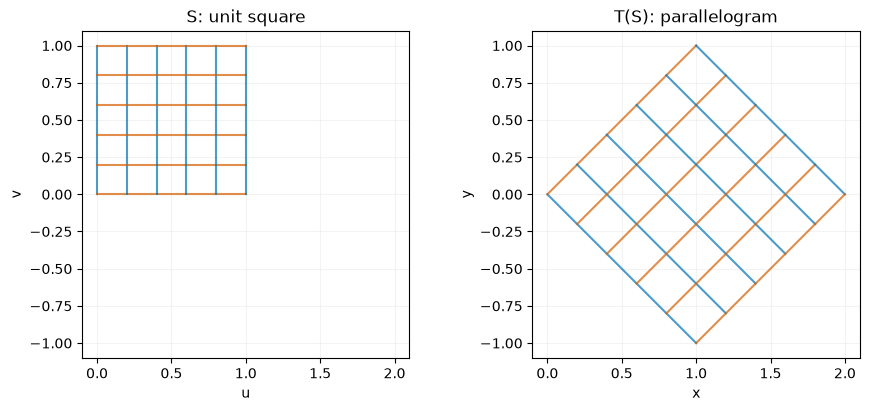

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
line = np.linspace(0, 1, 101)
for level in np.linspace(0, 1, 6):
    axes[0].plot(np.full_like(line, level), line, color="#0072B2", alpha=0.7)
    axes[0].plot(line, np.full_like(line, level), color="#D55E00", alpha=0.7)
    axes[1].plot(level + line, level - line, color="#0072B2", alpha=0.7)
    axes[1].plot(line + level, line - level, color="#D55E00", alpha=0.7)
axes[0].set(title="S: unit square", xlabel="u", ylabel="v")
axes[1].set(title="T(S): parallelogram", xlabel="x", ylabel="y")
for ax in axes:
    ax.set_aspect("equal")
    ax.set(xlim=(-0.1, 2.1), ylim=(-1.1, 1.1))
    ax.grid(alpha=0.15)
# 预期单位正方形变成顶点为 (0,0)、(1,1)、(2,0)、(1,-1) 的平行四边形，面积变为 2。
plt.show()  # 内部网格也随变换移动；右图面积是左图的 2 倍。

## 5 雅可比行列式与积分换元

先使用一组足够清楚的条件：$T$ 在所考虑的区域上可逆，其分量有连续一阶偏导数，并且内部的雅可比行列式非零；被积函数在像区域上连续，区域有适当的分段光滑边界。更一般的可积情形需要相应的换元定理，不能只检查一个数值行列式。

用 $J_T$ 表示 $2\times2$ 雅可比矩阵，行对应输出 $x,y$，列对应输入 $u,v$：

$$J_T=\begin{pmatrix}x_u&x_v\\y_u&y_v\end{pmatrix},
\quad\det J_T=x_u y_v-x_v y_u.$$

下标表示偏导数，例如 $x_u=\partial x/\partial u$。线性近似把小矩形的两条边变成两个向量，平行四边形面积的缩放因子是 $|\det J_T|$；负号只表示方向翻转。因此

$$\iint_{D_T} f(x,y)\,dx\,dy
=\iint_S f(T(u,v))\,|\det J_T(u,v)|\,du\,dv.$$

本例 $J_T=\begin{pmatrix}1&1\\1&-1\end{pmatrix}$，行列式为 $-2$。面积需要乘 2，不能乘 $-2$，也不能漏掉这个因子。

In [8]:
manual_det = 1 * (-1) - 1 * 1
library_det = np.linalg.det(transform)
mapped_area, _ = dblquad(lambda v, u: abs(manual_det), 0, 1, 0, 1)
wrong_signed_area, _ = dblquad(lambda v, u: manual_det, 0, 1, 0, 1)
print("手算行列式与 NumPy：", manual_det, library_det)  # 都为 -2。
print("面积：", mapped_area)  # 预期为 2。
print("误用有符号行列式：", wrong_signed_area)  # -2 不能作为面积。

手算行列式与 NumPy： -2 -2.0
面积： 2.0
误用有符号行列式： -2.0


现在计算 $f(x,y)=x^2+y^2$。先代入函数，再乘面积因子：

$$f(T(u,v))=(u+v)^2+(u-v)^2=2u^2+2v^2,$$

$$\iint_{D_T}(x^2+y^2)\,dA
=\int_0^1\int_0^1 4(u^2+v^2)\,dv\,du=\frac83.$$

若坚持使用 $x,y$，需要将像区域分成 $0\le x\le1$ 和 $1\le x\le2$ 两部分，分别取 $-x\le y\le x$ 和 $x-2\le y\le2-x$。两种计算应一致。

In [9]:
changed_value, changed_error = dblquad(lambda v, u: 4 * (u**2 + v**2), 0, 1, 0, 1)
left_value, _ = dblquad(lambda y, x: x**2 + y**2, 0, 1, lambda x: -x, lambda x: x)
right_value, _ = dblquad(
    lambda y, x: x**2 + y**2, 1, 2, lambda x: x - 2, lambda x: 2 - x
)
print("换元积分与分块积分：", changed_value, left_value + right_value)  # 预期约为 2.66667 2.66667。
print("与 8/3 的差：", abs(changed_value - 8 / 3))  # 本次数值约为 8.9e-16。
print("换元积分的误差估计：", changed_error)  # 本次数值约为 5.9e-14。
# 预期差异仅为浮点运算量级；区域、函数与面积因子已分别手算。

换元积分与分块积分： 2.6666666666666674 2.6666666666666665
与 8/3 的差： 8.881784197001252e-16
换元积分的误差估计： 5.901924333328645e-14


## 6 极坐标及边界上的例外

在单位圆盘上，设半径坐标 $r\ge0$、角度 $\theta$ 以弧度计。极坐标变换是

$$x=r\cos\theta,\qquad y=r\sin\theta.$$

其雅可比矩阵及行列式为

$$J=\begin{pmatrix}\cos\theta&-r\sin\theta\\\sin\theta&r\cos\theta\end{pmatrix},
\qquad \det J=r.$$

在 $0<r<1$、$0<\theta<2\pi$ 内变换一一对应且行列式非零。在 $r=0$，不同角度变成同一个原点；在角度区间两端，点也重复。原点与接缝在平面中面积为零，对本例的有界连续被积函数，不改变积分。也可以先去掉这些边界，再取极限。

单位圆盘的面积是 $\int_0^{2\pi}\int_0^1r\,dr\,d\theta=\pi$；而

$$\iint_{x^2+y^2\le1}(x^2+y^2)\,dA
=\int_0^{2\pi}\int_0^1 r^3\,dr\,d\theta=\frac\pi2.$$

面积因子 $r$ 之外，被积函数本身还贡献 $r^2$。

In [10]:
disk_area, _ = dblquad(lambda r, theta: r, 0, 2 * np.pi, 0, 1)
disk_moment, _ = dblquad(lambda r, theta: r**3, 0, 2 * np.pi, 0, 1)
print("圆盘面积与 pi 的差：", abs(disk_area - np.pi))  # 预期接近 0；本次计算为 0。
print("平方半径积分与 pi/2 的差：", abs(disk_moment - np.pi / 2))  # 预期接近 0；本次计算为 0。
print("漏掉面积因子后的面积：", 2 * np.pi)  # 错误结果，比真实面积大一倍。

for cutoff in [0.1, 0.01, 0.001]:
    annulus_area = np.pi * (1 - cutoff**2)
    # 面积差约为 0.031416、0.00031416、0.0000031416，每次缩小为 1/100。
    print(f"去掉半径 {cutoff:g} 的小圆：面积差 {np.pi - annulus_area:.6g}")
# 面积差等于 pi * cutoff**2，趋于 0；不能据此忽略任意奇异集合。

圆盘面积与 pi 的差： 0.0
平方半径积分与 pi/2 的差： 0.0
漏掉面积因子后的面积： 6.283185307179586
去掉半径 0.1 的小圆：面积差 0.0314159
去掉半径 0.01 的小圆：面积差 0.000314159
去掉半径 0.001 的小圆：面积差 3.14159e-06


## 7 一维密度也必须随长度变化

设实随机变量 $X$ 具有密度 $p_X$，$Y=g(X)$。先要求 $g$ 在 $X$ 取值的区间上严格单调、连续可微，且导数非零。写 $h=g^{-1}$ 为逆函数，则在像区间内

$$p_Y(y)=p_X(h(y))\,|h'(y)|
=\frac{p_X(x)}{|g'(x)|}\bigg|_{x=h(y)}.$$

像区间外的密度为零。原因是同一小段概率质量必须保留：$p_Y(y)\,|dy|=p_X(x)\,|dx|$。面积或长度拉长时，单位长度的密度需要降低。严格递增时，也可以从 $F_Y(y)=F_X(h(y))$ 求导；严格递减时不等号反向，绝对值保证密度非负。$F_X,F_Y$ 分别表示两者的累积分布函数。

例如 $X$ 在 $(0,1)$ 上均匀分布，$Y=3-2X$ 落在 $(1,3)$ 上，$h(y)=(3-y)/2$，所以 $p_Y(y)=1/2$。只代入逆函数而漏掉导数，会把总概率算成 2。

In [11]:
affine_mass, _ = quad(lambda y: 0.5, 1, 3)
wrong_affine_mass, _ = quad(lambda y: 1.0, 1, 3)
print("正确密度的总积分：", affine_mass)  # 预期为 1。
print("漏掉逆变换导数的总积分：", wrong_affine_mass)  # 预期为 2。
print("P(1 < Y < 2)：", quad(lambda y: 0.5, 1, 2)[0])  # 预期 0.5，对应 P(X > 0.5)。

正确密度的总积分： 1.0
漏掉逆变换导数的总积分： 2.0
P(1 < Y < 2)： 0.5


非线性变换需要随位置改变密度。令 $X$ 在 $(0,1)$ 上均匀分布，$Y=X^2$。在 $0<y<1$，

$$F_Y(y)=P(X\le\sqrt y)=\sqrt y,
\qquad p_Y(y)=\frac{1}{2\sqrt y}.$$

$y\le0$ 时累积分布函数为 0，$y\ge1$ 时为 1。密度在零附近无界，但归一化应通过正端点极限计算：$\lim_{\varepsilon\to0^+}\int_\varepsilon^1(2\sqrt y)^{-1}\,dy=\lim_{\varepsilon\to0^+}(1-\sqrt\varepsilon)=1$，其中 $0<\varepsilon<1$。因此局部无界不妨碍总概率为 1；$Y=0$ 没有正概率。端点密度的单点赋值不会改变连续分布。

下面比较累积分布函数和直方图。直方图每根柱的高度是区间平均密度，尤其第一根柱不能拿来和在零处发散的密度值比较。理论平均密度用每个箱子的概率除以箱宽得到。

In [12]:
rng_square = np.random.default_rng(2607)
sample_size = 30_000
x_positive = rng_square.uniform(0, 1, sample_size)
y_squared = x_positive**2
square_mass, square_error = quad(lambda y: 1 / (2 * np.sqrt(y)), 0, 1)
thresholds = np.array([0.04, 0.25, 0.64])
empirical_cdf = np.array([np.mean(y_squared <= value) for value in thresholds])
print("密度总积分与误差估计：", square_mass, square_error)  # 预期密度总积分接近 1；本次数值积分误差估计约 2.9e-15。
print("理论累积概率：", np.sqrt(thresholds))  # 预期约为 [0.2 0.5 0.8]。
print("本次样本频率：", empirical_cdf)  # 本次固定种子下约为 [0.2008 0.493833 0.796433]。
# 教学模拟假设各 X 独立同分布；固定种子不保证跨 NumPy 版本逐位一致。

密度总积分与误差估计： 0.9999999999999992 2.886579864025407e-15
理论累积概率： [0.2 0.5 0.8]
本次样本频率： [0.2008     0.49383333 0.79643333]


图中的 CDF 表示累积分布函数，density 表示单位横轴长度的概率密度。蓝色是样本结果，橙色是理论值；全部样本都纳入 $[0,1]$ 的直方图。

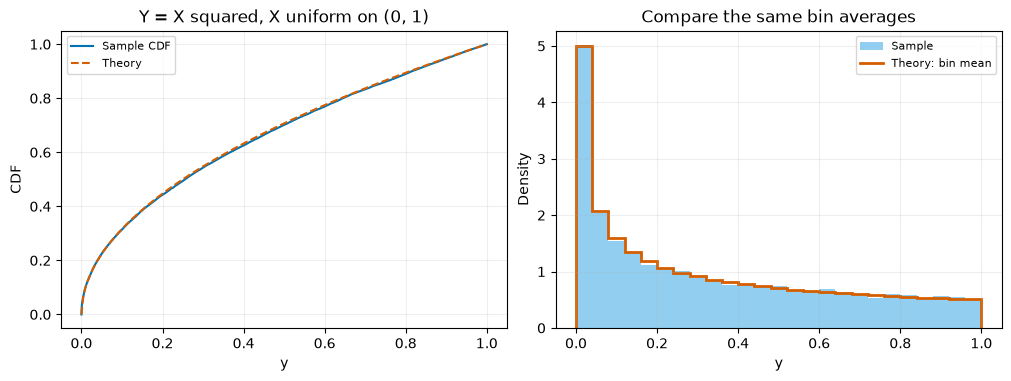

直方图总面积： 1.0
理论分箱面积： 1.0


In [13]:
bins = np.linspace(0, 1, 26)
# 每箱概率为 CDF 两端之差，再除箱宽得到理论平均密度，避开零点的无界密度值。
mean_density = np.diff(np.sqrt(bins)) / np.diff(bins)
sorted_y = np.sort(y_squared)
# 左图比较累计概率，右图比较相同分箱上的样本密度和理论平均密度。
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), layout="constrained")
axes[0].plot(
    sorted_y,
    np.arange(1, sample_size + 1) / sample_size,
    color="#0072B2",
    label="Sample CDF",
)
axes[0].plot(grid, np.sqrt(grid), color="#D55E00", linestyle="--", label="Theory")
heights, edges, _ = axes[1].hist(
    y_squared, bins=bins, density=True, color="#56B4E9", alpha=0.65, label="Sample"
)
axes[1].stairs(
    mean_density, bins, color="#D55E00", linewidth=2, label="Theory: bin mean"
)
axes[0].set(xlabel="y", ylabel="CDF", title="Y = X squared, X uniform on (0, 1)")
axes[1].set(xlabel="y", ylabel="Density", title="Compare the same bin averages")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
# 本次经验 CDF 接近 √y，密度柱在 0 附近较高；橙色阶梯比较的是每箱平均密度。
plt.show()
print("直方图总面积：", np.sum(heights * np.diff(edges)))  # 接近 1。
print("理论分箱面积：", np.sum(mean_density * np.diff(bins)))  # 接近 1。

## 8 多分支与不能直接套公式的情形

现在把输入改成 $X\sim\mathrm{Uniform}(-1,1)$，密度为 $1/2$，仍令 $Y=X^2$。平方不再一一对应：对于 $0<y<1$，原像有 $x=\sqrt y$ 与 $x=-\sqrt y$ 两个分支。

在有限个可分别反演、导数非零的分支上，应把各分支的概率贡献相加。设这些逆分支为 $h_k$，$k$ 遍历确实落在原支持集内的分支，则

$$p_Y(y)=\sum_k p_X(h_k(y))\,|h_k'(y)|.$$

本例每个分支贡献 $1/(4\sqrt y)$，总和仍为 $1/(2\sqrt y)$。只保留正根会漏掉一半概率。也可直接从事件计算：

$$F_Y(y)=P(-\sqrt y\le X\le\sqrt y)=\frac{2\sqrt y}{2}=\sqrt y.$$

$x=0$ 的导数为零，不能在该点直接除以导数。本例先分成正、负开区间，再由累积分布函数检查零点没有原子概率，即单点概率为零。

In [14]:
single_branch_mass, _ = quad(lambda y: 1 / (4 * np.sqrt(y)), 0, 1)
both_branch_mass, _ = quad(lambda y: 1 / (2 * np.sqrt(y)), 0, 1)
rng_branches = np.random.default_rng(2608)
x_signed = rng_branches.uniform(-1, 1, sample_size)
print("只算一个分支的总积分：", single_branch_mass)  # 接近 0.5。
print("两分支相加的总积分：", both_branch_mass)  # 接近 1。
print("平方后不超过 0.25 的样本比例：", np.mean(x_signed**2 <= 0.25))  # 本次固定种子下约为 0.4992。
# 理论概率是 0.5，输入区间变宽后，两个原像分支都必须计入。

只算一个分支的总积分： 0.4999999999999996
两分支相加的总积分： 0.9999999999999992
平方后不超过 0.25 的样本比例： 0.4992


如果一整段正概率的输入被压到一点，单纯的密度换元就不够了。例如 $Z=\max(X,0)$，仍使用上面的均匀输入，有 $P(Z=0)=P(X\le0)=1/2$。其余概率在 $(0,1)$ 上有密度 $1/2$。仅积分这段连续密度只得到 $1/2$，剩余部分是零点的原子概率，不能丢弃。

二维同理：$T(u,v)=(u,0)$ 把正方形全部压到一条线，雅可比行列式处处为零。若输入在正方形上均匀，输出在线上的概率是 1，却不存在相对于平面面积的普通联合密度。遇到这种降维、平坦区间或复杂临界集合时，应返回事件概率、累积分布函数或适用的分布表示，不能通过给分母加小数来修补换元公式。

In [15]:
z_clipped = np.maximum(x_signed, 0)
continuous_mass, _ = quad(lambda z: 0.5, 0, 1)
collapse_jacobian = np.array([[1.0, 0.0], [0.0, 0.0]])
print("零点的样本比例：", np.mean(z_clipped == 0))  # 本次约 0.500333，接近理论原子质量 0.5。
print("理论连续质量加原子质量：", continuous_mass + 0.5)  # 等于 1。
print("压缩到直线的雅可比行列式：", np.linalg.det(collapse_jacobian))  # 等于 0。

零点的样本比例： 0.5003333333333333
理论连续质量加原子质量： 1.0
压缩到直线的雅可比行列式： 0.0


## 9 二维密度变换的方向

设随机列向量 $\mathbf U=(U,V)^\mathsf T\in\mathbb R^2$ 具有联合密度 $p_{UV}$，而 $\mathbf X=(X,Y)^\mathsf T=T(\mathbf U)$。在第 5 节的可逆、连续可微且行列式非零的条件下，像区域内的密度满足

$$p_{XY}(x,y)=p_{UV}(T^{-1}(x,y))\,
\left|\det J_{T^{-1}}(x,y)\right|.$$

等价地，在 $(x,y)=T(u,v)$ 处有 $p_{XY}(T(u,v))=p_{UV}(u,v)/|\det J_T(u,v)|$。积分换元乘正向面积因子，输出密度除正向面积因子，两者共同保证概率质量不变。

以第 4 节的线性变换为例，$U,V$ 独立且均匀分布于 $(0,1)$，所以正方形内 $p_{UV}=1$，像区域 $D_T$ 内 $p_{XY}=1/2$，外部为零。根据竖直切片长度，$X$ 的边缘密度是 $x$（$0<x<1$）和 $2-x$（$1<x<2$），因此 $P(X\le1)=1/2$。

In [16]:
mass_left, _ = dblquad(lambda y, x: 0.5, 0, 1, lambda x: -x, lambda x: x)
mass_right, _ = dblquad(lambda y, x: 0.5, 1, 2, lambda x: x - 2, lambda x: 2 - x)
rng_plane = np.random.default_rng(2609)
uv_samples = rng_plane.uniform(0, 1, size=(sample_size, 2))
xy_samples = uv_samples @ transform.T
print("两个分块的概率质量：", mass_left, mass_right)  # 各为 0.5。
print("联合密度总积分：", mass_left + mass_right)  # 等于 1。
print("P(X <= 1) 的样本比例：", np.mean(xy_samples[:, 0] <= 1))  # 本次固定种子下约为 0.4934。
print("X、Y 的样本均值：", xy_samples.mean(axis=0))  # 本次约 [1.00411, 0.000287]，分别接近理论均值 1、0。

两个分块的概率质量： 0.5 0.5
联合密度总积分： 1.0
P(X <= 1) 的样本比例： 0.4934
X、Y 的样本均值： [1.00411007e+00 2.87114338e-04]


## 10 综合应用：在圆盘上均匀取点

目标是在单位圆盘内按面积均匀采样，即 $p_{XY}(x,y)=1/\pi$。这不等于让半径也均匀分布。

设 $R$ 是半径随机变量，$\Theta$ 是角度随机变量。由极坐标的面积因子，

$$p_{R,\Theta}(r,\theta)=\frac r\pi=(2r)\frac1{2\pi},
\qquad0<r<1,\quad0<\theta<2\pi.$$

因此可独立生成密度为 $2r$ 的半径和均匀角度。因为 $F_R(r)=r^2$，取相互独立的 $U,V\sim\mathrm{Uniform}(0,1)$，用

$$R=\sqrt U,\qquad\Theta=2\pi V,\qquad
X=R\cos\Theta,\quad Y=R\sin\Theta.$$

归一化为 $\int_0^{2\pi}\int_0^1(r/\pi)\,dr\,d\theta=1$。此外 $P(R\le1/2)=1/4$、$E[R^2]=\int_0^1r^2(2r)\,dr=1/2$，可作为两项独立的数值核对目标。作为对照，直接取 $R=U$ 会得到 $P(R\le1/2)=1/2$、$E[R^2]=1/3$，点会过于集中在圆心附近。

In [17]:
rng_disk = np.random.default_rng(2610)
disk_samples = rng_disk.uniform(0, 1, size=(sample_size, 2))
radius = np.sqrt(disk_samples[:, 0])
wrong_radius = disk_samples[:, 0]
angle = 2 * np.pi * disk_samples[:, 1]
disk_xy = np.column_stack((radius * np.cos(angle), radius * np.sin(angle)))
wrong_xy = np.column_stack((wrong_radius * np.cos(angle), wrong_radius * np.sin(angle)))
polar_mass, _ = dblquad(lambda r, theta: r / np.pi, 0, 2 * np.pi, 0, 1)
print("极坐标密度总积分：", polar_mass)  # 接近 1。
# 本次面积均匀样本的两项估计约 0.2507、0.498693，对照理论 1/4、1/2。
print(
    "正确半径：P(R <= 0.5)、E[R^2] 的估计：", np.mean(radius <= 0.5), np.mean(radius**2)
)
print("均匀半径：相应估计：", np.mean(wrong_radius <= 0.5), np.mean(wrong_radius**2))  # 本次均匀半径样本的两项估计约 0.503767、0.332362，对照其理论 1/2、1/3。
# 本次数值约为 3.3e-16。
print(
    "坐标与半径恒等式的最大残差：",
    np.max(np.abs(np.sum(disk_xy**2, axis=1) - radius**2)),
)
# 两种方法共用原始随机数以便比较；它们不是两组独立的实验。

极坐标密度总积分： 1.0
正确半径：P(R <= 0.5)、E[R^2] 的估计： 0.2507 0.4986931462801139
均匀半径：相应估计： 0.5037666666666667 0.3323622516861423
坐标与半径恒等式的最大残差： 3.3306690738754696e-16


散点图各展示前 1500 个点，第三幅图使用全部 30000 个点画半径的经验累积分布。圆心附近的差异既可从图上观察，也可从上一单元的区域概率中核对；不是只凭散点看起来是否均匀作判断。

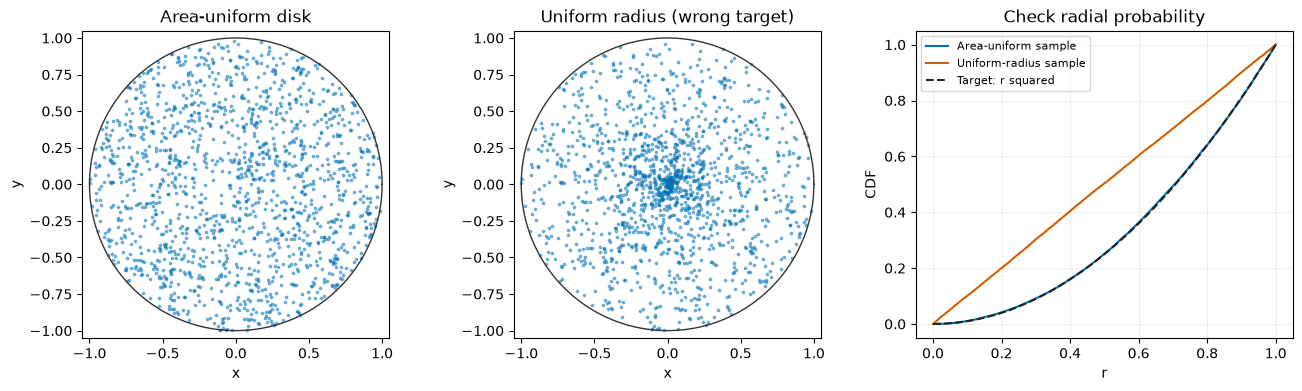

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained")
circle_angle = np.linspace(0, 2 * np.pi, 301)
# 前两图仅展示 1500 个点，并用同一圆边界、坐标范围和纵横比比较。
for ax, points, title in zip(
    axes[:2],
    [disk_xy, wrong_xy],
    ["Area-uniform disk", "Uniform radius (wrong target)"],
):
    ax.scatter(points[:1500, 0], points[:1500, 1], s=3, color="#0072B2", alpha=0.45)
    ax.plot(np.cos(circle_angle), np.sin(circle_angle), color="#333333", linewidth=1)
    ax.set(xlabel="x", ylabel="y", title=title, xlim=(-1.05, 1.05), ylim=(-1.05, 1.05))
    ax.set_aspect("equal")
# 第三图使用全部样本，将两种半径的经验 CDF 与目标 r² 对照。
cdf_levels = np.arange(1, sample_size + 1) / sample_size
axes[2].plot(np.sort(radius), cdf_levels, color="#0072B2", label="Area-uniform sample")
axes[2].plot(
    np.sort(wrong_radius), cdf_levels, color="#D55E00", label="Uniform-radius sample"
)
axes[2].plot(grid, grid**2, color="#222222", linestyle="--", label="Target: r squared")
axes[2].set(xlabel="r", ylabel="CDF", title="Check radial probability")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)
# 本次正确样本在圆盘面积上较均匀，均匀半径样本偏向中心；两条径向 CDF 分别靠近 r²、r。
plt.show()  # 正确方案的半径 CDF 贴近 r**2；错误方案接近 r。

## 本章小结

（1）先描述区域，再决定累次积分界限。换序可能需要分块；连续紧域、绝对可积与非负函数分别提供不同范围的保证。

（2）积分换元同时改变区域、被积函数和面积因子。雅可比矩阵的行列式可以为负，但面积因子取绝对值。

（3）密度变换保留概率质量。使用逆变换的雅可比因子，或除以正向因子，并核对支持集和归一化。

（4）多分支需要累加贡献；临界点应单独判断。区域压成低维集合或区间压成一点时，普通密度公式可能不再适用。

理解自查：能否解释为什么换序不是交换两个微分符号，为什么密度与面积因子方向相反，以及为什么均匀半径不能产生面积均匀的圆盘样本？

## 练习

（1）将三角形换成 $D=\{(x,y):0\le x\le2,\ 0\le y\le x/2\}$，计算 $\iint_D x\,dA$。分别写出两种次序的界限，手算后用 dblquad 核对。两次计算应在 $10^{-10}$ 的绝对误差内一致；再说明为什么直接交换原界限会改变区域。

In [19]:
x_max = 2.0
boundary_slope = 0.5
print("区域参数：", x_max, boundary_slope)
# 在这里补充手算结果、两种累次积分及其差值。
# 提示：先求 y 的整体范围，再对固定 y 求 x 的范围。

区域参数： 2.0 0.5


（2）令 $x=2u+v$、$y=u+2v$，其中 $(u,v)\in[0,1]^2$。求像区域的四个顶点、面积和区域内均匀分布的密度。核对积分为 1，并解释使用正向雅可比因子乘原密度为什么不对。注意本题的变换矩阵与正文不同。

In [20]:
exercise_transform = np.array([[2.0, 1.0], [1.0, 2.0]])
exercise_vertices = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])
print("输入顶点：\n", exercise_vertices)
# 补充映射后的顶点、手算行列式、面积与密度归一化。

输入顶点：
 [[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]


（3）设 $X$ 在 $(-2,1)$ 上均匀分布，$Y=X^2$。判断 $0<y<1$ 和 $1<y<4$ 分别有几个有效逆分支，写出分段密度。用分段积分检查总质量为 1，再计算 $P(Y\le1)$ 并与事件 $-1\le X\le1$ 的长度比核对。不能沿用正文两个分支处处存在的假设。

In [21]:
exercise_low, exercise_high = -2.0, 1.0
exercise_density = 1 / (exercise_high - exercise_low)
print("原均匀密度：", exercise_density)
# 分别处理 (0, 1) 与 (1, 4)，再核对总概率和指定事件概率。
# 在文字中说明临界值 y=0 与分支变化点 y=1 的处理。

原均匀密度： 0.3333333333333333


（4）目标改为在圆环 $1\le x^2+y^2\le4$ 上按面积均匀取点。推导半径累积分布函数和由 $U\sim\mathrm{Uniform}(0,1)$ 生成半径的方法，再与均匀半径比较。用 30000 个样本核对归一化及 $P(R^2\le2.5)$，说明样本频率存在随机误差；同时判断角度取 $0$ 到 $4\pi$ 后直接套一一对应换元公式会出现什么问题。

In [22]:
inner_radius, outer_radius = 1.0, 2.0
rng_exercise = np.random.default_rng(2614)
exercise_uniforms = rng_exercise.uniform(0, 1, size=(30_000, 2))
print("圆环半径范围：", inner_radius, outer_radius)
# 一列生成半径，一列生成角度；先推导面积对应的 CDF，再写代码。
# 对角度覆盖两次的情形，说明如何缩小角度区间或显式处理覆盖次数。

圆环半径范围： 1.0 2.0


## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先列出平方的两个逆分支，再逐一检查是否落在原支持区间。

提示 2：每个合法分支贡献原密度乘逆导数绝对值；归一化在分支数变化处拆分。

### 练习（3）参考解析

原密度为 1/3。当 $0<y<1$，$\pm\sqrt y$ 都属于 $(-2,1)$，密度为 $1/(3\sqrt y)$；当 $1<y<4$，仅负分支合法，密度为 $1/(6\sqrt y)$；区间外为零。

第一段反常积分为 $\lim_{\varepsilon\to0^+}\frac23(1-\sqrt\varepsilon)=2/3$，第二段积分为 $\frac13(2-1)=1/3$，总和为 1。因此 $P(Y\le1)=2/3$，也等于 $[-1,1]$ 与原支持相交的长度 2 除以总长度 3。零点需用积分极限处理；y=1 是分支变化点，这些单点处的密度取值不改变概率。

## 参考与引用来源

下列来源于 2026-09-21 核查。理论条件与 API 约定分别对应；本章的具体区域、数值和教学模拟按所列公式另行计算。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax | [Calculus Volume 2，§3.7](https://openstax.org/books/calculus-volume-2/pages/3-7-improper-integrals) 的式 (3.20)：无界左端点的反常积分极限；[Calculus Volume 3，§5.2](https://openstax.org/books/calculus-volume-3/pages/5-2-double-integrals-over-general-regions)：第一型与第二型区域、定理 5.4、分块定理 5.5、换序；[§5.7](https://openstax.org/books/calculus-volume-3/pages/5-7-change-of-variables-in-multiple-integrals)：平面变换、Jacobian、定理 5.14 的一一对应与内部非零条件、例 5.67 和 5.69 的极坐标因子。 |
| Random Services，Kyle Siegrist 作者教材 | [Properties of the Integral](https://www.randomservices.org/random/foundations/Properties.html)：Fubini's Theorem 段、非负与绝对可积的条件，以及 Examples and Applications → Counterexamples 中的正方形反例。这里只转述其数学结论，不展开测度论证明。 |
| Deep Learning 作者网站 | [第 3 章，§3.12，式 3.44–3.47，印刷页 69–70](https://www.deeplearningbook.org/contents/prob.html)：零测集、一维与向量密度的变量变换、概率质量与雅可比行列式。 |
| Berkeley Prob 140 课程教材 | [§16.2 Monotone Functions](https://data140.org/fa18/textbook/chapters/Chapter_16/02_Monotone_Functions)：由 CDF 采样、单调函数的密度变换与导数绝对值；[§16.3 Two-to-One Functions](https://data140.org/fa18/textbook/chapters/Chapter_16/03_Two_to_One_Functions)：平方变换的正负逆分支、CDF 方法与分支贡献相加。 |
| SciPy 官方文档 | 1.18 系列：[dblquad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.dblquad.html) 的内外变量参数次序、边界函数、误差估计与收敛要求；[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) 的定积分、反常积分与误差返回值。 |
| NumPy 官方文档 | 2.5 系列：[Generator](https://numpy.org/doc/stable/reference/random/generator.html) 的局部生成器、种子与版本兼容边界；[uniform](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html) 的区间和输出形状；[linalg.det](https://numpy.org/doc/stable/reference/generated/numpy.linalg.det.html) 的方阵行列式。 |
| Matplotlib 官方文档 | 3.11 系列：[fill_between](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) 的区域填充；[hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) 的分箱边界、density 归一化和返回值，用于把直方图与理论分箱平均密度比较。 |